# Cloud Map (Low / Mid / High)
Notebook nay doc du lieu GRIB, trich xuat 3 tang may (`low`, `mid`, `high`) va tao ban do may nang cao cho khu vuc Viet Nam.

In [25]:
# Chay cell nay neu kernel chua co thu vien can thiet.
# Neu da cai roi, co the bo qua.
%pip install -q numpy xarray cfgrib folium branca pillow

Note: you may need to restart the kernel to use updated packages.


In [26]:
import numpy as np
import xarray as xr
import cfgrib
import folium
from folium.raster_layers import ImageOverlay
from folium.plugins import Fullscreen
from branca.colormap import LinearColormap
from PIL import Image, ImageFilter

DATA_FILE = "gdas.t06z.pgrb2.0p25.f000"
VN_BOUNDS = {
    "lat_min": 8.0,
    "lat_max": 24.0,
    "lon_min": 102.0,
    "lon_max": 110.0,
}


def _to_2d_latlon(da: xr.DataArray) -> xr.DataArray:
    """Chuyen DataArray ve dang 2D (latitude, longitude)."""
    da = da.squeeze(drop=True)
    for dim in list(da.dims):
        if dim not in ("latitude", "longitude", "lat", "lon"):
            da = da.isel({dim: 0})

    rename_map = {}
    if "lat" in da.dims:
        rename_map["lat"] = "latitude"
    if "lon" in da.dims:
        rename_map["lon"] = "longitude"
    if rename_map:
        da = da.rename(rename_map)

    if da.longitude.max() > 180:
        da = da.assign_coords(longitude=((da.longitude + 180) % 360) - 180).sortby("longitude")

    return da


def _normalize_cloud(arr: np.ndarray) -> np.ndarray:
    arr = np.asarray(arr, dtype=np.float32)
    arr = np.nan_to_num(arr, nan=0.0)
    vmin, vmax = float(np.nanmin(arr)), float(np.nanmax(arr))

    if vmax <= 1.05:
        return np.clip(arr, 0.0, 1.0)
    if vmax <= 100.5:
        return np.clip(arr / 100.0, 0.0, 1.0)

    if vmax - vmin < 1e-9:
        return np.zeros_like(arr)

    scaled = (arr - vmin) / (vmax - vmin)
    return np.clip(scaled, 0.0, 1.0)


def _subset_vietnam(da: xr.DataArray) -> xr.DataArray:
    return da.sel(
        latitude=slice(VN_BOUNDS["lat_max"], VN_BOUNDS["lat_min"]),
        longitude=slice(VN_BOUNDS["lon_min"], VN_BOUNDS["lon_max"]),
    )


def load_cloud_layers(grib_file: str):
    datasets = cfgrib.open_datasets(grib_file)

    def pick_layer(candidates):
        for ds in datasets:
            for name in candidates:
                if name in ds.data_vars:
                    return _subset_vietnam(_to_2d_latlon(ds[name])), name
        available = sorted({var for ds in datasets for var in ds.data_vars})
        raise ValueError(f"Khong tim thay layer trong {candidates}. Bien co san: {available}")

    low_da, low_name = pick_layer(["lcdc", "lcc", "tcc"]) 
    mid_da, mid_name = pick_layer(["mcdc", "mcc", "tcc"]) 
    high_da, high_name = pick_layer(["hcdc", "hcc", "tcc"]) 

    return {
        "low": _normalize_cloud(low_da.values),
        "mid": _normalize_cloud(mid_da.values),
        "high": _normalize_cloud(high_da.values),
        "lat": low_da.latitude.values,
        "lon": low_da.longitude.values,
        "names": {"low": low_name, "mid": mid_name, "high": high_name},
    }

cloud = load_cloud_layers(DATA_FILE)
print("Da nap xong cloud layers:", cloud["names"])
print("Grid shape:", cloud["low"].shape)

Da nap xong cloud layers: {'low': 'lcc', 'mid': 'mcc', 'high': 'hcc'}
Grid shape: (65, 33)


In [27]:
# Kiem tra nhanh chat luong du lieu cloud truoc khi ve ban do.
for k in ["low", "mid", "high"]:
    arr = cloud[k]
    print(
        f"{k:>4} | shape={arr.shape} | min={np.nanmin(arr):.3f} | max={np.nanmax(arr):.3f} "
        f"| mean={np.nanmean(arr):.3f} | nan%={np.isnan(arr).mean()*100:.2f} | nonzero%={(arr>0).mean()*100:.2f}"
    )

print("lat range:", float(cloud["lat"].min()), "->", float(cloud["lat"].max()), "len=", cloud["lat"].size)
print("lon range:", float(cloud["lon"].min()), "->", float(cloud["lon"].max()), "len=", cloud["lon"].size)

 low | shape=(65, 33) | min=0.000 | max=0.000 | mean=0.000 | nan%=0.00 | nonzero%=0.00
 mid | shape=(65, 33) | min=0.000 | max=0.000 | mean=0.000 | nan%=0.00 | nonzero%=0.00
high | shape=(65, 33) | min=0.000 | max=0.000 | mean=0.000 | nan%=0.00 | nonzero%=0.00
lat range: 8.0 -> 24.0 len= 65
lon range: 102.0 -> 110.0 len= 33


In [28]:
# Soat cac bien lien quan den may trong GRIB va thong ke nhanh min/max.
datasets = cfgrib.open_datasets(DATA_FILE)
cloud_like = ["lcdc", "mcdc", "hcdc", "lcc", "mcc", "hcc", "tcc", "cdcb", "cdct"]

for i, ds in enumerate(datasets):
    names = [n for n in ds.data_vars if n in cloud_like]
    if not names:
        continue
    print(f"Dataset #{i} -> cloud vars: {names}")
    for n in names:
        da = _to_2d_latlon(ds[n])
        da = _subset_vietnam(da)
        arr = np.asarray(da.values, dtype=np.float32)
        print(f"  {n:>4}: min={np.nanmin(arr):.3f}, max={np.nanmax(arr):.3f}, mean={np.nanmean(arr):.3f}")

Dataset #0 -> cloud vars: ['hcc']
   hcc: min=nan, max=nan, mean=nan
Dataset #1 -> cloud vars: ['lcc']
   lcc: min=nan, max=nan, mean=nan
Dataset #2 -> cloud vars: ['mcc']
   mcc: min=nan, max=nan, mean=nan


C:\Users\MSI\AppData\Local\Temp\ipykernel_25192\1063626157.py:14: RuntimeWarning: All-NaN slice encountered
  print(f"  {n:>4}: min={np.nanmin(arr):.3f}, max={np.nanmax(arr):.3f}, mean={np.nanmean(arr):.3f}")
C:\Users\MSI\AppData\Local\Temp\ipykernel_25192\1063626157.py:14: RuntimeWarning: Mean of empty slice
  print(f"  {n:>4}: min={np.nanmin(arr):.3f}, max={np.nanmax(arr):.3f}, mean={np.nanmean(arr):.3f}")
C:\Users\MSI\AppData\Local\Temp\ipykernel_25192\1063626157.py:14: RuntimeWarning: All-NaN slice encountered
  print(f"  {n:>4}: min={np.nanmin(arr):.3f}, max={np.nanmax(arr):.3f}, mean={np.nanmean(arr):.3f}")
C:\Users\MSI\AppData\Local\Temp\ipykernel_25192\1063626157.py:14: RuntimeWarning: Mean of empty slice
  print(f"  {n:>4}: min={np.nanmin(arr):.3f}, max={np.nanmax(arr):.3f}, mean={np.nanmean(arr):.3f}")
C:\Users\MSI\AppData\Local\Temp\ipykernel_25192\1063626157.py:14: RuntimeWarning: All-NaN slice encountered
  print(f"  {n:>4}: min={np.nanmin(arr):.3f}, max={np.nanmax(arr):.3

In [29]:
# Kiem tra nhanh toan bo grid (khong cat Viet Nam) de xem file co gia tri cloud hay khong.
for i, ds in enumerate(datasets):
    for n in [v for v in ds.data_vars if v in ["lcc", "mcc", "hcc"]]:
        raw = _to_2d_latlon(ds[n]).values.astype(np.float32)
        finite_ratio = np.isfinite(raw).mean() * 100
        print(f"Dataset #{i} {n}: finite%={finite_ratio:.2f}")

Dataset #0 hcc: finite%=0.00
Dataset #1 lcc: finite%=1.62
Dataset #2 mcc: finite%=0.00


In [30]:
# Xac dinh vi tri lat/lon co gia tri hop le cho lcc.
lcc_ds = [ds for ds in datasets if "lcc" in ds.data_vars][0]
lcc_da = _to_2d_latlon(lcc_ds["lcc"])
arr = lcc_da.values.astype(np.float32)
mask = np.isfinite(arr)

if mask.any():
    iy, ix = np.where(mask)
    lat_vals = lcc_da.latitude.values[iy]
    lon_vals = lcc_da.longitude.values[ix]
    print("lcc finite lat range:", float(np.min(lat_vals)), "->", float(np.max(lat_vals)))
    print("lcc finite lon range:", float(np.min(lon_vals)), "->", float(np.max(lon_vals)))
else:
    print("Khong co diem finite cho lcc")

vn = _subset_vietnam(lcc_da).values.astype(np.float32)
print("VN finite%:", np.isfinite(vn).mean() * 100)

lcc finite lat range: -85.5 -> 43.5
lcc finite lon range: -78.25 -> 113.0
VN finite%: 0.0


In [31]:
# Liet ke nhanh cac bien co chuoi 'cc' hoac 'cdc' de ban co the chon bien khac.
all_vars = sorted({v for ds in datasets for v in ds.data_vars})
print([v for v in all_vars if ("cc" in v or "cdc" in v or "cld" in v)])

['hcc', 'lcc', 'mcc']


In [32]:
# Nap lai cloud tren toan bo grid (khong cat theo Viet Nam).
def load_cloud_layers_global(grib_file: str):
    datasets = cfgrib.open_datasets(grib_file)

    def pick_layer(candidates):
        for ds in datasets:
            for name in candidates:
                if name in ds.data_vars:
                    return _to_2d_latlon(ds[name]), name
        available = sorted({var for ds in datasets for var in ds.data_vars})
        raise ValueError(f"Khong tim thay layer trong {candidates}. Bien co san: {available}")

    low_da, low_name = pick_layer(["lcdc", "lcc", "tcc"])
    mid_da, mid_name = pick_layer(["mcdc", "mcc", "tcc"])
    high_da, high_name = pick_layer(["hcdc", "hcc", "tcc"])

    return {
        "low": _normalize_cloud(low_da.values),
        "mid": _normalize_cloud(mid_da.values),
        "high": _normalize_cloud(high_da.values),
        "lat": low_da.latitude.values,
        "lon": low_da.longitude.values,
        "names": {"low": low_name, "mid": mid_name, "high": high_name},
    }

cloud = load_cloud_layers_global(DATA_FILE)
print("Da nap cloud toan bo grid:", cloud["names"])
print("Grid shape moi:", cloud["low"].shape)
print("nonzero% low/mid/high:", (cloud["low"] > 0).mean() * 100, (cloud["mid"] > 0).mean() * 100, (cloud["high"] > 0).mean() * 100)

Da nap cloud toan bo grid: {'low': 'lcc', 'mid': 'mcc', 'high': 'hcc'}
Grid shape moi: (721, 1440)
nonzero% low/mid/high: 0.0 0.0 0.0


In [33]:
# Ve truc tiep cac diem cloud hop le (finite) tu raw lcc, khong gioi han theo Viet Nam.
lcc_ds = [ds for ds in cfgrib.open_datasets(DATA_FILE) if "lcc" in ds.data_vars][0]
lcc_da = _to_2d_latlon(lcc_ds["lcc"])
raw = np.asarray(lcc_da.values, dtype=np.float32)
mask = np.isfinite(raw)

lat2d, lon2d = np.meshgrid(lcc_da.latitude.values, lcc_da.longitude.values, indexing="ij")
pts_lat = lat2d[mask]
pts_lon = lon2d[mask]

point_map = folium.Map(location=[0, 0], zoom_start=2, tiles="CartoDB positron", control_scale=True)

# Giam mat do diem de map nhe hon neu so diem qua lon.
step = max(1, len(pts_lat) // 3000)
for la, lo in zip(pts_lat[::step], pts_lon[::step]):
    folium.CircleMarker(
        location=[float(la), float(lo)],
        radius=1.2,
        color="#2b83ba",
        fill=True,
        fill_color="#2b83ba",
        fill_opacity=0.75,
        opacity=0.75,
        weight=0,
    ).add_to(point_map)

if len(pts_lat) > 0:
    point_map.fit_bounds([
        [float(np.min(pts_lat)), float(np.min(pts_lon))],
        [float(np.max(pts_lat)), float(np.max(pts_lon))],
    ])

print(f"Tong so diem finite: {len(pts_lat)} | So diem da ve: {len(pts_lat[::step])}")
point_map

Tong so diem finite: 16857 | So diem da ve: 3372


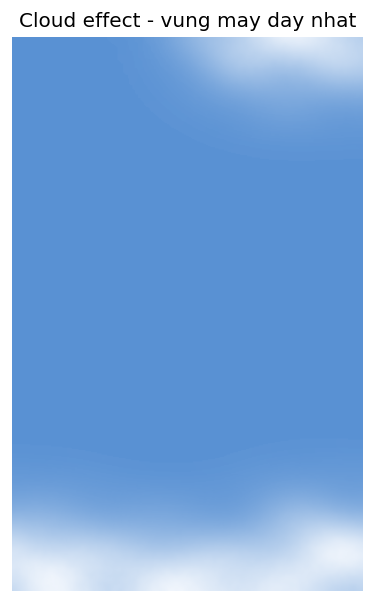

Thong tin anh: {'crop_box': (0, 484, 560, 866), 'crop_shape': (484, 306), 'local_max': 0.8352941274642944}


In [35]:
# Hien thi anh may tai vung co mat do may cao nhat, khong xuat HTML.
import matplotlib.pyplot as plt


def _blur01(arr, radius):
    arr_u8 = np.uint8(np.clip(arr, 0, 1) * 255)
    return np.asarray(Image.fromarray(arr_u8, mode="L").filter(ImageFilter.GaussianBlur(radius=radius)), dtype=np.float32) / 255.0


def render_dense_cloud_image(lat_points, lon_points, out_h=520, out_w=920, blur_radius=10.0):
    lat_min, lat_max = float(np.min(lat_points)), float(np.max(lat_points))
    lon_min, lon_max = float(np.min(lon_points)), float(np.max(lon_points))

    density = np.zeros((out_h, out_w), dtype=np.float32)

    iy = ((lat_points - lat_min) / (lat_max - lat_min + 1e-9) * (out_h - 1)).astype(np.int32)
    ix = ((lon_points - lon_min) / (lon_max - lon_min + 1e-9) * (out_w - 1)).astype(np.int32)
    iy = np.clip(iy, 0, out_h - 1)
    ix = np.clip(ix, 0, out_w - 1)
    np.add.at(density, (iy, ix), 1.0)

    base = np.clip(density / (density.max() + 1e-9), 0, 1)
    smooth = _blur01(base, blur_radius)

    # Cat theo cum may day nhat.
    thr = np.quantile(smooth[smooth > 0], 0.92) if np.any(smooth > 0) else 0.0
    mask = smooth >= thr
    if np.any(mask):
        ys, xs = np.where(mask)
        y0, y1 = int(np.min(ys)), int(np.max(ys) + 1)
        x0, x1 = int(np.min(xs)), int(np.max(xs) + 1)
    else:
        peak_y, peak_x = np.unravel_index(np.argmax(smooth), smooth.shape)
        y0, y1 = max(0, peak_y - 120), min(smooth.shape[0], peak_y + 120)
        x0, x1 = max(0, peak_x - 160), min(smooth.shape[1], peak_x + 160)

    anchor = smooth[y0:y1, x0:x1]
    if anchor.size == 0:
        raise ValueError("Khong tim duoc vung cloud hop le de render")

    local_max = float(np.max(anchor))
    if local_max > 1e-8:
        anchor = np.clip(anchor / local_max, 0.0, 1.0)

    # Lam lan rong phan bo may de tranh anh bi mot dai sat mep.
    spread = np.clip(0.60 * _blur01(anchor, 14) + 0.40 * _blur01(anchor, 30), 0.0, 1.0)

    # Tao noise nhieu tang de cloud nhin that hon.
    h, w = spread.shape
    yy, xx = np.indices((h, w))
    rng = np.random.default_rng(42)
    noise = (
        0.45 * (np.sin(xx / 17.0) * np.cos(yy / 13.0))
        + 0.30 * (np.sin((xx + yy) / 23.0))
        + 0.20 * (np.cos(xx / 41.0 - yy / 29.0))
        + 0.15 * rng.normal(0.0, 1.0, size=(h, w))
    )
    noise = _blur01((noise - noise.min()) / (noise.max() - noise.min() + 1e-9), 2.0)

    # Truong alpha cloud: du lieu thuc (spread) + cau truc noise.
    cloud_alpha = np.clip((spread ** 0.75) * (0.55 + 0.85 * noise), 0.0, 1.0)
    cloud_alpha = np.clip(cloud_alpha ** 0.90, 0.0, 1.0)

    rgba = _layer_rgba(cloud_alpha, tint_rgb=(250, 252, 255), alpha_scale=1.0)

    rgb = rgba[..., :3].astype(np.float32) / 255.0
    alpha = np.clip((rgba[..., 3:4].astype(np.float32) / 255.0), 0.0, 1.0)
    sky = np.array([0.35, 0.57, 0.83], dtype=np.float32).reshape(1, 1, 3)
    cloud_img = rgb * alpha + sky * (1.0 - alpha)

    fig, ax = plt.subplots(figsize=(9, 6), dpi=120)
    ax.imshow(cloud_img, origin="lower")
    ax.set_title("Cloud effect - vung may day nhat", fontsize=12)
    ax.axis("off")
    plt.show()

    return {
        "crop_box": (int(y0), int(y1), int(x0), int(x1)),
        "crop_shape": cloud_alpha.shape,
        "local_max": local_max,
    }


cloud_image_info = render_dense_cloud_image(pts_lat, pts_lon)
print("Thong tin anh:", cloud_image_info)

In [36]:
# Khong xuat file HTML. Anh may noi suy duoc hien thi truc tiep trong cell render.
print("Da bo xuat file HTML cho map noi suy.")

Da bo xuat file HTML cho map noi suy.



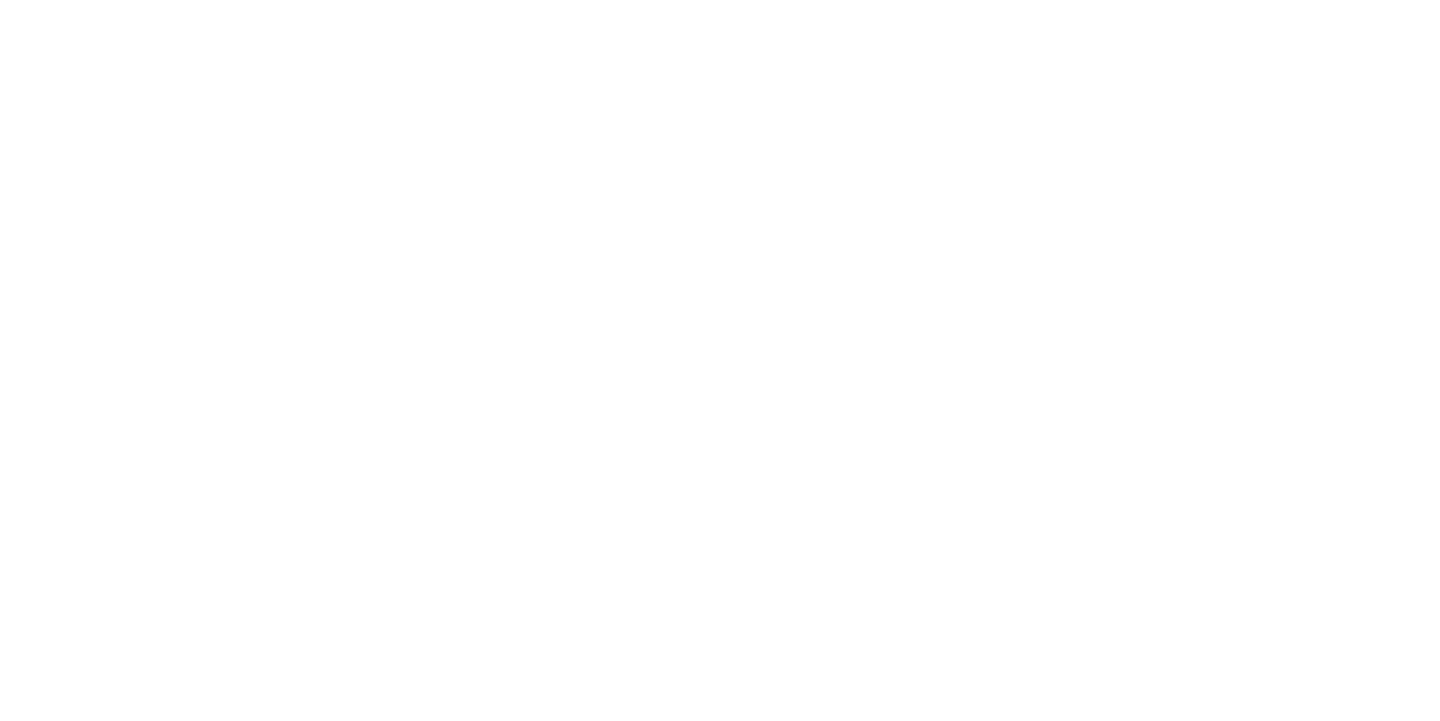
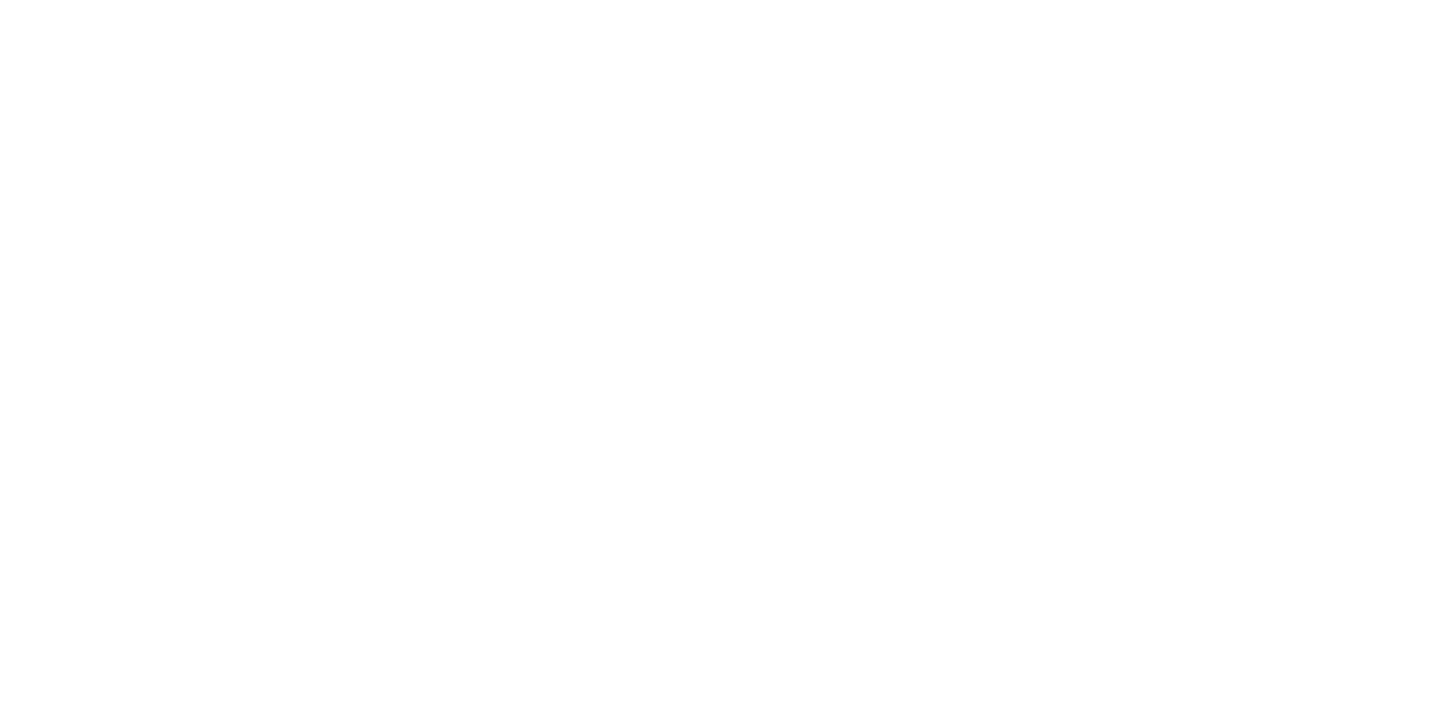
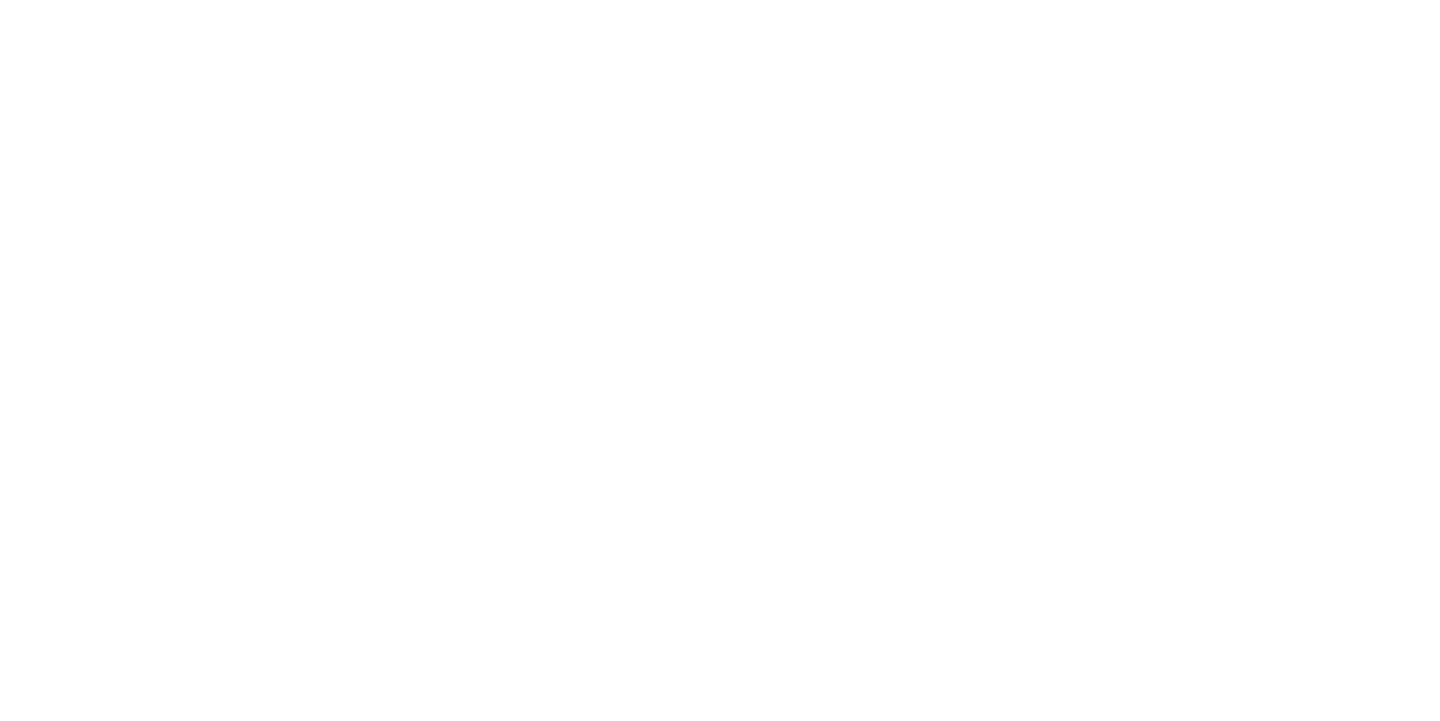
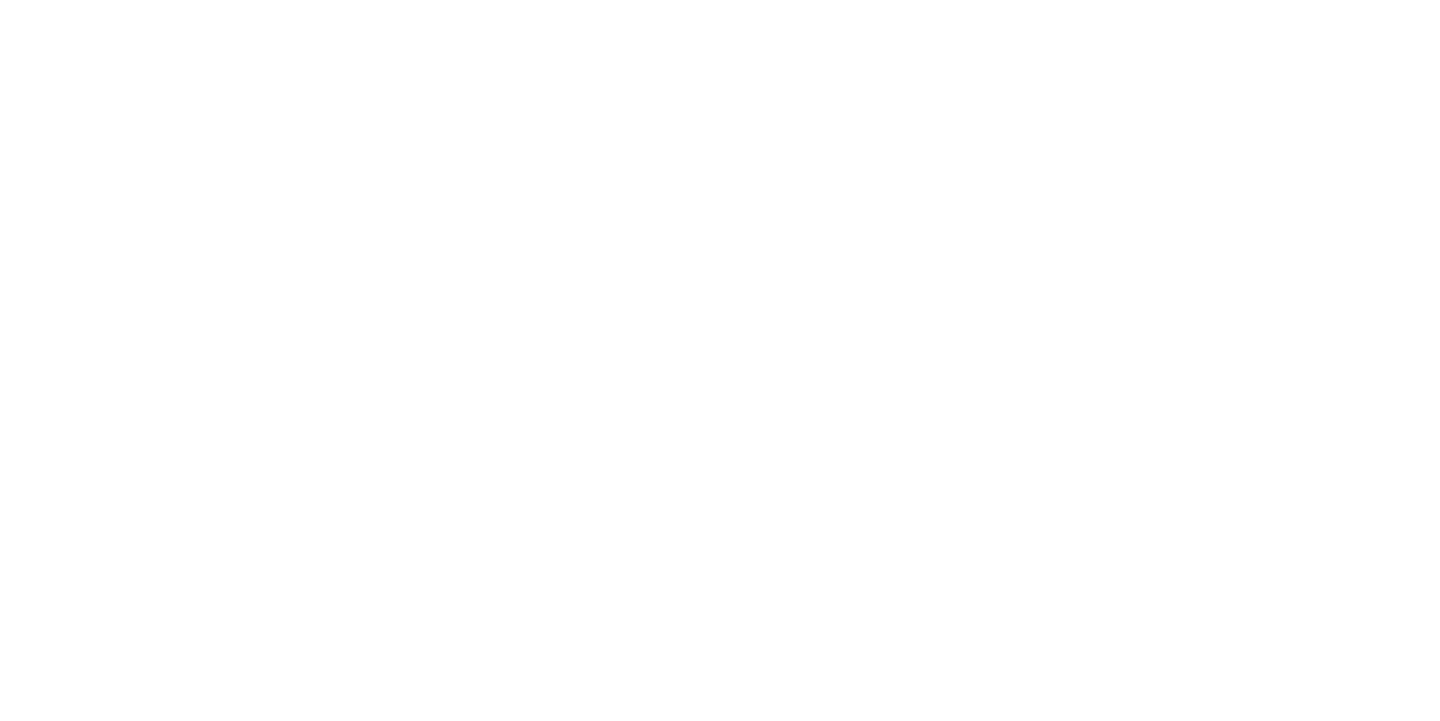

In [37]:
def _layer_rgba(intensity: np.ndarray, tint_rgb, alpha_scale: float = 1.0) -> np.ndarray:
    intensity = np.clip(intensity, 0.0, 1.0)
    h, w = intensity.shape
    rgba = np.zeros((h, w, 4), dtype=np.uint8)

    r, g, b = tint_rgb
    rgba[..., 0] = np.uint8(r)
    rgba[..., 1] = np.uint8(g)
    rgba[..., 2] = np.uint8(b)

    alpha = np.clip((intensity ** 0.85) * 255.0 * alpha_scale, 0, 255)
    rgba[..., 3] = alpha.astype(np.uint8)
    return rgba


def _composite_cloud(low: np.ndarray, mid: np.ndarray, high: np.ndarray) -> np.ndarray:
    # Trong so tao hieu ung may tang cao mong, tang thap day hon.
    weighted = np.clip(0.50 * low + 0.32 * mid + 0.18 * high, 0.0, 1.0)

    # Them texture nhe de tranh mat may bi phang.
    yy, xx = np.indices(weighted.shape)
    texture = 0.06 * np.sin(xx / 5.5) + 0.05 * np.cos(yy / 4.0)
    texture += 0.04 * np.sin((xx + yy) / 8.5)
    enhanced = np.clip(weighted + texture * weighted, 0.0, 1.0)

    rgba = _layer_rgba(enhanced, tint_rgb=(248, 251, 255), alpha_scale=0.95)

    # Lam muot nhe de tao visual cloud tu nhien.
    img = Image.fromarray(rgba, mode="RGBA")
    img = img.filter(ImageFilter.GaussianBlur(radius=1.4))
    return np.array(img)


def _build_map(cloud_data):
    lat = cloud_data["lat"]
    lon = cloud_data["lon"]
    low = cloud_data["low"]
    mid = cloud_data["mid"]
    high = cloud_data["high"]

    bounds = [[float(lat.min()), float(lon.min())], [float(lat.max()), float(lon.max())]]
    center = [(bounds[0][0] + bounds[1][0]) / 2, (bounds[0][1] + bounds[1][1]) / 2]

    m = folium.Map(
        location=center,
        zoom_start=6,
        tiles="CartoDB positron",
        control_scale=True,
    )

    # 3 layer rieng + 1 layer tong hop cloud style nang cao.
    low_rgba = _layer_rgba(low, tint_rgb=(220, 234, 255), alpha_scale=0.55)
    mid_rgba = _layer_rgba(mid, tint_rgb=(238, 241, 255), alpha_scale=0.7)
    high_rgba = _layer_rgba(high, tint_rgb=(255, 255, 255), alpha_scale=0.85)
    composite_rgba = _composite_cloud(low, mid, high)

    ImageOverlay(image=low_rgba, bounds=bounds, name="Cloud Low", opacity=1.0, interactive=False).add_to(m)
    ImageOverlay(image=mid_rgba, bounds=bounds, name="Cloud Mid", opacity=1.0, interactive=False).add_to(m)
    ImageOverlay(image=high_rgba, bounds=bounds, name="Cloud High", opacity=1.0, interactive=False).add_to(m)
    ImageOverlay(image=composite_rgba, bounds=bounds, name="Cloud Composite (Enhanced)", opacity=1.0, interactive=False).add_to(m)

    folium.LayerControl(collapsed=False).add_to(m)
    Fullscreen(position="topright", title="Full Screen", title_cancel="Exit").add_to(m)

    # Khung gioi han map vao Viet Nam.
    m.fit_bounds(bounds)
    return m

cloud_map = _build_map(cloud)
cloud_map

## Mo ta ngan ve pipeline
1. Doc du lieu GRIB va tim bien may cho 3 tang: low/mid/high (uu tien `lcdc`, `mcdc`, `hcdc`; fallback `lcc/mcc/hcc/tcc`).
2. Chuan hoa du lieu may ve khoang `[0, 1]`, xu ly linh hoat cho ca truong hop du lieu dang % hoac fraction.
3. Cat du lieu theo pham vi Viet Nam: lat `8 -> 24`, lon `102 -> 110`.
4. Tao 4 overlay tren Folium:
   - `Cloud Low`
   - `Cloud Mid`
   - `Cloud High`
   - `Cloud Composite (Enhanced)`
5. Custom giao dien may nang cao bang trong so layer + texture song sin + Gaussian blur de may mem va tu nhien hon.
6. Luu ket qua ra file HTML: `cloud_vietnam_advanced_map.html`.

In [38]:
# Khong xuat file HTML tu pipeline cu.
print("Da bo xuat file HTML tu pipeline cu.")

Da bo xuat file HTML tu pipeline cu.
